# Simple Denoising Autoencoder (DAE) for MNIST
Paper [Here](https://www.cs.toronto.edu/~larocheh/publications/icml-2008-denoising-autoencoders.pdf)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt

# MNIST dataset
from tensorflow.keras.datasets import mnist

# Keras layers and Model API
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

## Preprocessing Data

In [ ]:
# Load dataset (60k train, 10k test images)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values from [0, 255] → [0, 1]
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

# Flatten images from (28, 28) → (784,)
x_train = x_train.reshape(len(x_train), (x_train.shape[1]*x_train.shape[2]))
x_test = x_test.reshape(len(x_test), (x_test.shape[1]*x_test.shape[2]))


In [ ]:
# Check shape → (num_samples, 784)
x_train.shape

(60000, 784)

# Model

In [ ]:
# Size of latent representation
encoding_dim = 12

# Input layer (784 features)
input_img = Input(shape = (784, ))

# Encoder part
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder part
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Full autoencoder model
autoencoder = Model(input_img, decoded)

In [ ]:
# Encoder model (maps input → latent space)
encoder = Model(input_img, encoded)

# Build standalone decoder model
encoded_input = Input(shape=(encoding_dim, ))

# Reuse last two layers from autoencoder
decode_layer1 = autoencoder.layers[-2]
decode_layer2 = autoencoder.layers[-1]

# Decoder model (maps latent space → reconstruction)
decoder = Model(encoded_input, decode_layer2(decode_layer1(encoded_input)))

In [ ]:
# Binary crossentropy because outputs are pixel values in [0,1]
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train to reconstruct original clean images
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    validation_data=(x_test, x_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0106 - loss: 0.1600 - val_accuracy: 0.0119 - val_loss: 0.1304
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0106 - loss: 0.1270 - val_accuracy: 0.0100 - val_loss: 0.1222
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0106 - loss: 0.1210 - val_accuracy: 0.0121 - val_loss: 0.1176
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0112 - loss: 0.1177 - val_accuracy: 0.0111 - val_loss: 0.1151
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0119 - loss: 0.1157 - val_accuracy: 0.0148 - val_loss: 0.1139


In [ ]:
# Compress test images
encoded_images = encoder.predict(x_test)
encoded_images.shape

# Reconstruct from latent space
predicted = decoder.predict(encoded_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


# Plot Encoding

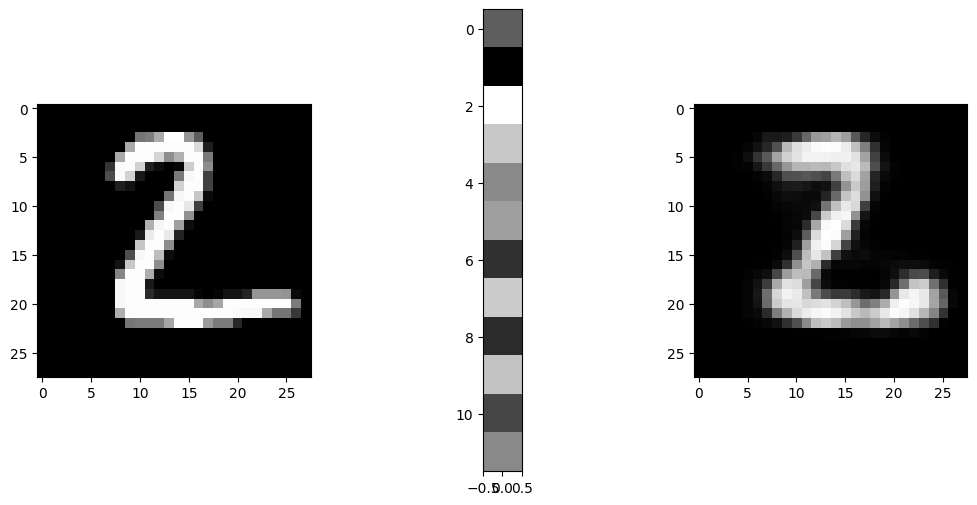

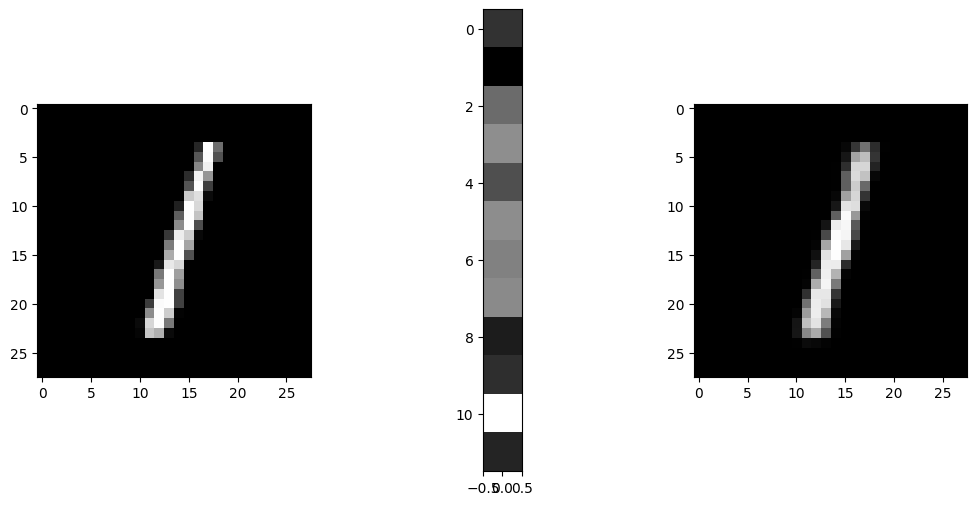

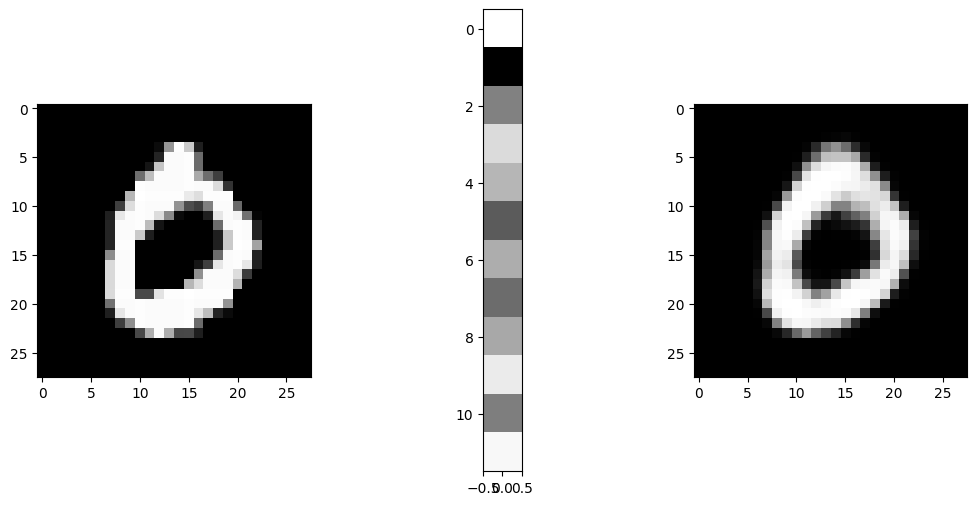

In [ ]:
def plot_imgs(index=0):
  f = plt.figure(figsize=(12, 6))
  
  # Original image
  f.add_subplot(1,3, 1)
  plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
  
  # Latent representation (12-d vector visualized as column)
  f.add_subplot(1,3, 2)
  plt.imshow(encoded_images[index].reshape(-1, 1), cmap="gray")
  
  # Reconstructed image
  f.add_subplot(1,3, 3)
  plt.imshow(predicted[index].reshape(28, 28), cmap="gray")
  
  plt.show(block=True)

# Plot examples
plot_imgs(1)
plot_imgs(2)
plot_imgs(3)

# Denoising Example

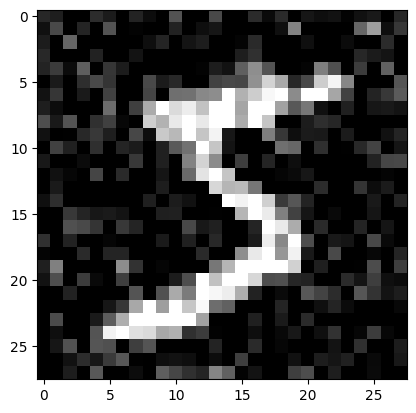

In [ ]:
noise_factor = 0.2

# Add Gaussian noise
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to keep them in valid pixel range [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Visualize a noisy image
plt.imshow(x_train_noisy[0].reshape(28, 28), cmap="gray")

# Model

In [ ]:
input_img = Input(shape = (784, ))

# Encoder
d_encoded = Dense(128, activation='relu')(input_img)
d_encoded = Dense(encoding_dim, activation='relu')(d_encoded)

# Decoder
d_decoded = Dense(128, activation='relu')(d_encoded)
d_decoded = Dense(784, activation='sigmoid')(d_decoded)

# Full denoising autoencoder
d_autoencoder = Model(input_img, d_decoded)

# Encoder only
d_encoder = Model(input_img, d_encoded)

# Decoder only
d_encoded_input = Input(shape=(encoding_dim, ))
d_decode_layer1 = d_autoencoder.layers[-2]
d_decode_layer2 = d_autoencoder.layers[-1]

d_decoder = Model(
    d_encoded_input,
    d_decode_layer2(d_decode_layer1(d_encoded_input))
)


In [ ]:
d_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Input = noisy images
# Target = clean images
history = d_autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0115 - loss: 0.1668 - val_accuracy: 0.0085 - val_loss: 0.1401
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0109 - loss: 0.1367 - val_accuracy: 0.0112 - val_loss: 0.1317
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0111 - loss: 0.1308 - val_accuracy: 0.0091 - val_loss: 0.1275
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0110 - loss: 0.1272 - val_accuracy: 0.0107 - val_loss: 0.1245
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0105 - loss: 0.1249 - val_accuracy: 0.0129 - val_loss: 0.1229


In [ ]:
# Reconstruct from noisy test images
encoded_images = d_encoder.predict(x_test_noisy)
reconstruct = d_decoder.predict(encoded_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


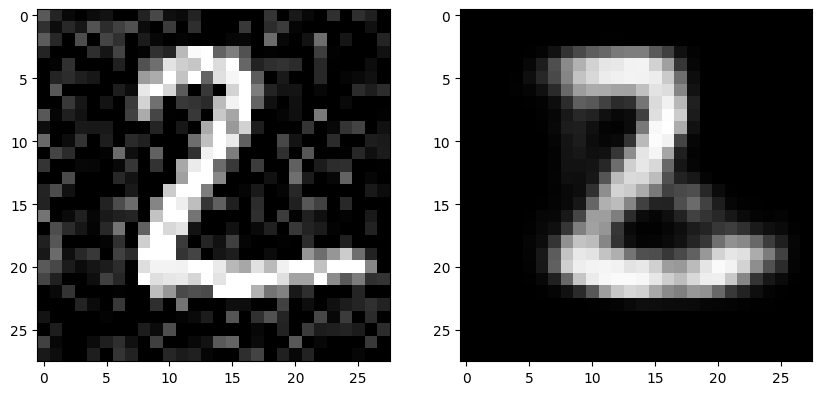

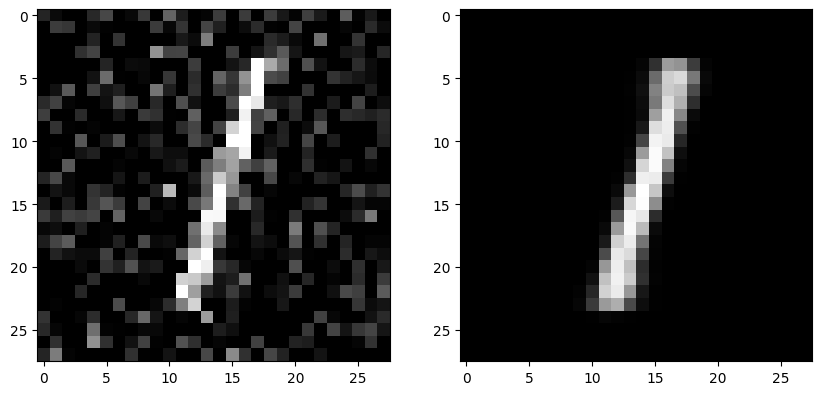

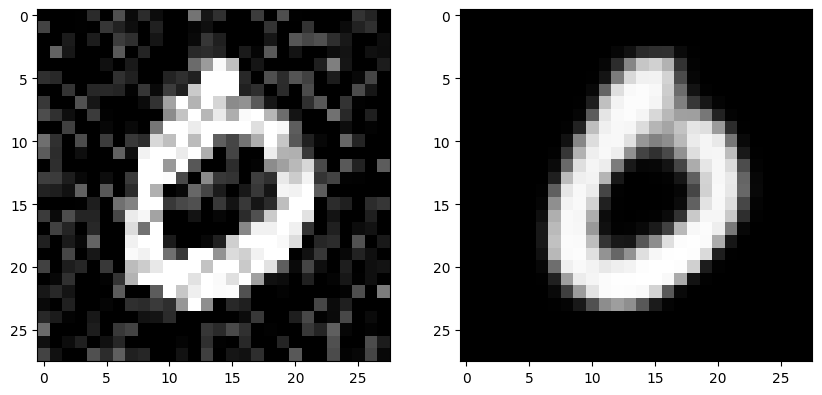

In [ ]:
def plot_imgs_for_cnn_noisy(index=0):
  f = plt.figure(figsize=(10, 10))
  
  # Noisy input
  f.add_subplot(1,2, 1)
  plt.imshow(x_test_noisy[index].reshape(28, 28), cmap="gray")

  # Reconstructed (denoised) output
  f.add_subplot(1,2, 2)
  plt.imshow(reconstruct[index].reshape(28,28), cmap="gray")

plot_imgs_for_cnn_noisy(1)
plot_imgs_for_cnn_noisy(2)
plot_imgs_for_cnn_noisy(3)


# Activity

1. Create a DAE for **CIFAR10** Dataset using Convolutional Layers
2. Try using *Mean Squared Error (MSE)* as Loss Function for Training
3. Compare Results with *Binary Cross-entropy* and *MSE* loss functions
4. Improve the model and test with **Noise ratios of: [0.2, 0.5, 0.8]**
   1. Add more epochs
   2. More layers/neurons
   3. Add Data Augmentation
   4. Change Encoding Dim

**This activity is in Teams!**